# Q2 — Unsupervised Learning

Segment retail customers using K-Means and visualise the segments in a 2-D PCA projection.

## 1. Data Preparation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("../data/q2_customers.csv")
print("Shape:", data.shape)
data.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
X_scaled_data = pd.DataFrame(X_scaled, columns=data.columns)
X_scaled_data.describe().round(2)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.56,-1.33,-1.39,-1.09,-1.00,-1.50
25%,-0.86,-0.90,-0.83,-0.86,-0.75,-0.68
50%,0.04,-0.14,-0.08,-0.28,-0.33,-0.27
75%,0.66,0.81,0.67,0.68,0.24,0.55
max,1.98,2.16,1.99,2.33,2.61,1.78


**Reasoning for applying K-means:**

In this dataset *annual_spend* ranges in the tens of thousands while *visits_per_month* and *num_categories_purchased* range in single to double digits. 
Without standardisation, the distance metric is dominated by *annual_spend* (and to a lesser extent *basket_size*) the other four features relatively contribute very little to cluster formation. Using K-Means will assign points to clusters by the Euclidean distance in the feature space. By Standard-scaling every feature to zero mean and unit variance, will put all of them on a comparable footing so K-Means can find a structure that will reflect all six parameters rather than just total spend or basket size.

## 2. Choosing K - Elbow method

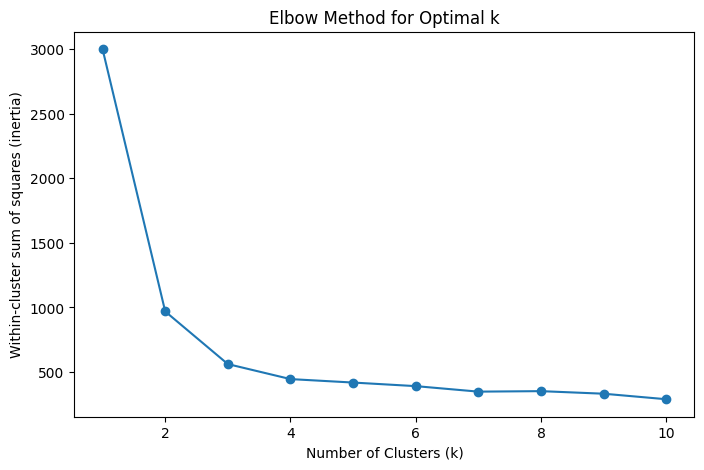

,k,wcss (inertia)
0,1,3000.0
1,2,969.0
2,3,561.3
3,4,445.0
4,5,418.2
5,6,390.5
6,7,347.9
7,8,351.7
8,9,331.8
9,10,289.1


In [12]:
from sklearn.cluster import KMeans

ks = range(1, 11)
inertia = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_data)
    inertia.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(ks), inertia, marker="o")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Within-cluster sum of squares (inertia)")
ax.set_title("Elbow Method for Optimal k")
plt.show()

pd.DataFrame({"k": list(ks), "wcss (inertia)": np.round(inertia, 1)})

The inertia curve drops steeply from K=1 to K=3 and then flattens noticeably — each additional cluster after K=3 shaves only a small amount off the WCSS. The clearest elbow therefore sits at **K = 3**. This gives an interpretable number of customer segments for the business to act on.